# Transformer-Hybrid (CNN + BiLSTM + Transformer) - PTB-XL

**Architecture:** 1D CNN front-end -> 2-layer BiLSTM -> Transformer Encoder -> mean-pool + linear classifier.

**References (no older than 2023):**
- Mehmood et al., *A joint CNN-Bi-LSTM-transformer architecture with SHAP explanations for multi-label arrhythmia detection from 12-lead ECGs*, **Nature Scientific Reports, 2026** - [link](https://www.nature.com/articles/s41598-026-40925-5)
- Khan et al., *DeepECG-Net: a hybrid transformer-based deep learning model for real-time ECG anomaly detection*, **Nature Scientific Reports, 2025** - [link](https://www.nature.com/articles/s41598-025-07781-1)
- Du et al., *xLSTM-ECG: Multi-label ECG Classification via Feature Fusion with xLSTM*, **arXiv 2504.16101, 2025** - [link](https://arxiv.org/abs/2504.16101)

**Task:** Multi-label classification - MI, STTC, CD, HYP (PTB-XL superclasses).


## 0 . Install dependencies

In [1]:
import subprocess, sys
def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])
for mod, pkg in [('sklearn','scikit-learn'), ('seaborn','seaborn'),
                 ('scipy','scipy'), ('iterstrat','iterative-stratification')]:
    try: __import__(mod)
    except ImportError: pip_install(pkg)
print('Dependencies ready.')


Dependencies ready.


## 1 . Imports & config

In [2]:
import os, pickle, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import f1_score, multilabel_confusion_matrix, roc_auc_score
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style('whitegrid')

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

NOTEBOOK_DIR = Path('.')
PKL_DIR      = Path('../PTB-XL-ECG')
CKPT_DIR     = NOTEBOOK_DIR / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)

CLASS_NAMES  = ['MI', 'STTC', 'CD', 'HYP']
NUM_CLASSES  = len(CLASS_NAMES)

NORM_CAP      = 4000
BATCH_SIZE    = 256
EPOCHS        = 50
LR            = 3e-4
WEIGHT_DECAY  = 1e-4
PATIENCE      = 15
WARMUP_EPOCHS = 5
THRESHOLD     = 0.5
USE_FOCAL     = True
FOCAL_GAMMA   = 2.0
FOCAL_ALPHA   = 0.25

DEVICE = (
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Device: {DEVICE}  |  CKPT_DIR: {CKPT_DIR}')


Device: cuda  |  CKPT_DIR: checkpoints


## 2 . Load data

In [3]:
def load_pkl(p):
    with open(p, 'rb') as f: return pickle.load(f)

X_train = np.array(load_pkl(PKL_DIR / 'X_train_processed.pickle'), dtype=np.float32).transpose(0,2,1)
y_train = np.array(load_pkl(PKL_DIR / 'y_train_processed.pickle'), dtype=np.float32)
X_val   = np.array(load_pkl(PKL_DIR / 'X_dev_processed.pickle'),   dtype=np.float32).transpose(0,2,1)
y_val   = np.array(load_pkl(PKL_DIR / 'y_dev_processed.pickle'),   dtype=np.float32)
X_test  = np.array(load_pkl(PKL_DIR / 'X_test_processed.pickle'),  dtype=np.float32).transpose(0,2,1)
y_test  = np.array(load_pkl(PKL_DIR / 'y_test_processed.pickle'),  dtype=np.float32)

print(f'Train {X_train.shape}  Val {X_val.shape}  Test {X_test.shape}')


Train (17111, 12, 1000)  Val (2156, 12, 1000)  Test (2163, 12, 1000)


## 3 . NORM undersampling & stratified split

In [4]:
X_all = np.concatenate([X_train, X_val, X_test], axis=0)
y_all = np.concatenate([y_train, y_val, y_test], axis=0)

rng         = np.random.default_rng(SEED)
norm_idx    = np.where(y_all.sum(axis=1) == 0)[0]
disease_idx = np.where(y_all.sum(axis=1) > 0)[0]
if len(norm_idx) > NORM_CAP:
    norm_idx = rng.choice(norm_idx, NORM_CAP, replace=False)
bal_idx      = np.concatenate([disease_idx, norm_idx])
X_bal, y_bal = X_all[bal_idx], y_all[bal_idx]

print(f'Balanced dataset: {len(X_bal)} samples  (NORM={(y_bal.sum(1)==0).sum()})')

norm_col = (y_bal.sum(1) == 0).astype(np.float32)[:, None]
y_strat  = np.concatenate([y_bal, norm_col], axis=1)

msss1 = MultilabelStratifiedShuffleSplit(1, test_size=0.15, random_state=SEED)
tv_idx, test_idx = next(msss1.split(X_bal, y_strat))
X_tv, y_tv   = X_bal[tv_idx],   y_bal[tv_idx]
X_test_split = X_bal[test_idx]; y_test_split = y_bal[test_idx]

norm_tv  = (y_tv.sum(1)==0).astype(np.float32)[:,None]
y_tv_str = np.concatenate([y_tv, norm_tv], axis=1)
msss2 = MultilabelStratifiedShuffleSplit(1, test_size=0.176, random_state=SEED)
tr_idx2, val_idx2 = next(msss2.split(X_tv, y_tv_str))
X_train_split, y_train_split = X_tv[tr_idx2],  y_tv[tr_idx2]
X_val_split,   y_val_split   = X_tv[val_idx2], y_tv[val_idx2]

print(f'Train {len(X_train_split)} | Val {len(X_val_split)} | Test {len(X_test_split)}')


Balanced dataset: 16347 samples  (NORM=4000)
Train 11474 | Val 2424 | Test 2449


## 4 . Dataset & DataLoaders

In [5]:
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

_kw = dict(batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)
tr_loader  = DataLoader(ECGDataset(X_train_split, y_train_split), shuffle=True,  **_kw)
val_loader = DataLoader(ECGDataset(X_val_split,   y_val_split),   shuffle=False, **_kw)
te_loader  = DataLoader(ECGDataset(X_test_split,  y_test_split),  shuffle=False, **_kw)
print(f'Loaders ready  |  batch_size={BATCH_SIZE}')


Loaders ready  |  batch_size=256


## 5 . Loss function

In [6]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma
    def forward(self, logits, targets):
        bce     = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p_t     = torch.exp(-bce)
        alpha_t = targets * self.alpha + (1 - targets) * (1 - self.alpha)
        return (alpha_t * (1 - p_t) ** self.gamma * bce).mean()

criterion = FocalLoss(FOCAL_ALPHA, FOCAL_GAMMA) if USE_FOCAL else nn.BCEWithLogitsLoss()
print(f'Loss: {"Focal" if USE_FOCAL else "BCE"}')


Loss: Focal


## 6 . Model - CNN + BiLSTM + Transformer

A joint hybrid that combines morphological CNN features, BiLSTM temporal modelling,
and Transformer self-attention for long-range dependencies. Architecture is adapted
from Mehmood et al. (Nature Sci Reports, 2026).


In [7]:
class CNN_BiLSTM_Transformer(nn.Module):
    """
    CNN + BiLSTM + Transformer Encoder hybrid for 12-lead ECG multi-label
    classification.

    Reference:
      Mehmood et al., "A joint CNN-Bi-LSTM-transformer architecture with SHAP
      explanations for multi-label arrhythmia detection from 12-lead ECGs",
      Nature Scientific Reports, 2026.
      https://www.nature.com/articles/s41598-026-40925-5

    Stage 1 - 1D CNN front-end captures morphological features (P/QRS/T waves)
              from raw multi-lead ECG.
    Stage 2 - 2-layer BiLSTM models local temporal dependencies on the CNN
              token sequence.
    Stage 3 - TransformerEncoder (multi-head self-attention) captures long-range
              beat-to-beat dependencies with learned positional embeddings.
    Stage 4 - Mean-pool over time + linear classification head returning logits.

    Input  : (B, 12, 1000) - 12-lead ECG @ 100 Hz, 10-second window
    Output : (B, n_classes) raw logits (sigmoid applied externally)
    """
    def __init__(self, n_classes=NUM_CLASSES, n_leads=12,
                 d_model=256, lstm_hidden=128, n_heads=8,
                 n_transformer_layers=2, ff_dim=512, dropout=0.2):
        super().__init__()

        # Stage 1 - 1D CNN front-end
        self.cnn = nn.Sequential(
            nn.Conv1d(n_leads,  64, kernel_size=15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(64),  nn.GELU(), nn.MaxPool1d(2),
            nn.Conv1d(64,      128, kernel_size=11, stride=1, padding=5, bias=False),
            nn.BatchNorm1d(128), nn.GELU(), nn.MaxPool1d(2),
            nn.Conv1d(128,     192, kernel_size=7,  stride=1, padding=3, bias=False),
            nn.BatchNorm1d(192), nn.GELU(), nn.MaxPool1d(2),
            nn.Conv1d(192, d_model, kernel_size=5,  stride=1, padding=2, bias=False),
            nn.BatchNorm1d(d_model), nn.GELU(),
        )

        # Stage 2 - BiLSTM temporal encoder
        self.bilstm = nn.LSTM(
            input_size=d_model, hidden_size=lstm_hidden, num_layers=2,
            batch_first=True, bidirectional=True, dropout=dropout,
        )
        # BiLSTM output = 2 * lstm_hidden = d_model

        # Stage 3 - Transformer encoder with learned positional embedding
        self.pos_embed = nn.Parameter(torch.zeros(1, 512, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=ff_dim,
            dropout=dropout, activation='gelu', batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_transformer_layers)
        self.norm = nn.LayerNorm(d_model)

        # Stage 4 - classifier
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, n_classes)

    def forward(self, x):                     # x : (B, 12, 1000)
        feat = self.cnn(x)                    # (B, 256, T')
        feat = feat.permute(0, 2, 1)          # (B, T', 256)

        lstm_out, _ = self.bilstm(feat)       # (B, T', 256)

        T = lstm_out.size(1)
        out = lstm_out + self.pos_embed[:, :T, :]
        out = self.transformer(out)           # (B, T', 256)
        out = self.norm(out)

        pooled = out.mean(dim=1)              # (B, 256)
        return self.classifier(self.dropout(pooled))   # logits

model = CNN_BiLSTM_Transformer().to(DEVICE)
total = sum(p.numel() for p in model.parameters())
train_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'CNN_BiLSTM_Transformer  |  total params: {total:,}  trainable: {train_p:,}')


CNN_BiLSTM_Transformer  |  total params: 2,498,052  trainable: 2,498,052


## 7 . Training

In [8]:
def compute_metrics(probs, targets, threshold=THRESHOLD):
    thr   = np.array(threshold) if not np.isscalar(threshold) else threshold
    preds = (probs >= thr).astype(int)
    mcm   = multilabel_confusion_matrix(targets.astype(int), preds)
    res   = {}
    for i, cls in enumerate(CLASS_NAMES):
        tn, fp, fn, tp = mcm[i].ravel()
        res[cls] = dict(
            sensitivity = tp/(tp+fn+1e-8),
            specificity = tn/(tn+fp+1e-8),
            accuracy    = (tp+tn)/(tp+tn+fp+fn+1e-8),
            f1          = 2*tp/(2*tp+fp+fn+1e-8),
        )
    for m in ('sensitivity','specificity','accuracy','f1'):
        res[f'macro_{m}'] = np.mean([res[c][m] for c in CLASS_NAMES])
    return res

def run_epoch(loader, mdl, crit, opt=None):
    training = opt is not None
    mdl.train(training)
    total_loss, all_probs, all_tgts = 0.0, [], []
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = mdl(xb)
            loss   = crit(logits, yb)
            if training:
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(mdl.parameters(), 1.0); opt.step()
            total_loss += loss.item() * len(xb)
            all_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
            all_tgts.append(yb.detach().cpu().numpy())
    return total_loss/len(loader.dataset), np.concatenate(all_probs), np.concatenate(all_tgts)


In [9]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=5)

best_f1, best_state, best_ep, no_improve = -1.0, None, 0, 0
history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    tr_loss, _,  _   = run_epoch(tr_loader,  model, criterion, optimizer)
    val_loss, vp, vt = run_epoch(val_loader, model, criterion)
    scheduler.step(val_loss)
    vf1 = compute_metrics(vp, vt)['macro_f1']
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(vf1)
    marker = ''
    if epoch > WARMUP_EPOCHS:
        if vf1 > best_f1:
            best_f1, best_ep = vf1, epoch
            best_state  = {k: v.cpu().clone() for k,v in model.state_dict().items()}
            torch.save(best_state, CKPT_DIR / 'best_model.pt')
            no_improve  = 0; marker = ' *'
        else:
            no_improve += 1
    print(f'Ep {epoch:3d} | tr {tr_loss:.4f} | val {val_loss:.4f} | F1 {vf1:.4f} | {time.time()-t0:5.1f}s{marker}')
    if epoch > WARMUP_EPOCHS and no_improve >= PATIENCE:
        print(f'Early stop at epoch {epoch}  (best val F1={best_f1:.4f} @ ep {best_ep})')
        break
print(f'\nBest val macro-F1 = {best_f1:.4f}  @ epoch {best_ep}')


Ep   1 | tr 0.0501 | val 0.0433 | F1 0.3785 |   1.9s
Ep   2 | tr 0.0389 | val 0.0393 | F1 0.5653 |   1.6s
Ep   3 | tr 0.0363 | val 0.0377 | F1 0.5577 |   1.4s
Ep   4 | tr 0.0343 | val 0.0385 | F1 0.5684 |   1.4s
Ep   5 | tr 0.0327 | val 0.0371 | F1 0.5365 |   1.4s
Ep   6 | tr 0.0317 | val 0.0383 | F1 0.6020 |   1.4s *
Ep   7 | tr 0.0301 | val 0.0441 | F1 0.6183 |   1.4s *
Ep   8 | tr 0.0284 | val 0.0399 | F1 0.5993 |   1.4s
Ep   9 | tr 0.0267 | val 0.0438 | F1 0.5962 |   1.4s
Ep  10 | tr 0.0251 | val 0.0447 | F1 0.6016 |   1.4s
Ep  11 | tr 0.0238 | val 0.0492 | F1 0.5974 |   1.4s
Ep  12 | tr 0.0184 | val 0.0819 | F1 0.5979 |   1.4s
Ep  13 | tr 0.0154 | val 0.0595 | F1 0.6347 |   1.4s *
Ep  14 | tr 0.0137 | val 0.0800 | F1 0.6621 |   1.4s *
Ep  15 | tr 0.0115 | val 0.0784 | F1 0.6870 |   1.5s *
Ep  16 | tr 0.0113 | val 0.0711 | F1 0.6591 |   1.4s
Ep  17 | tr 0.0098 | val 0.1186 | F1 0.7013 |   1.5s *
Ep  18 | tr 0.0063 | val 0.0921 | F1 0.6896 |   1.4s
Ep  19 | tr 0.0043 | val 0.1114 | 

## 8 . Training curves

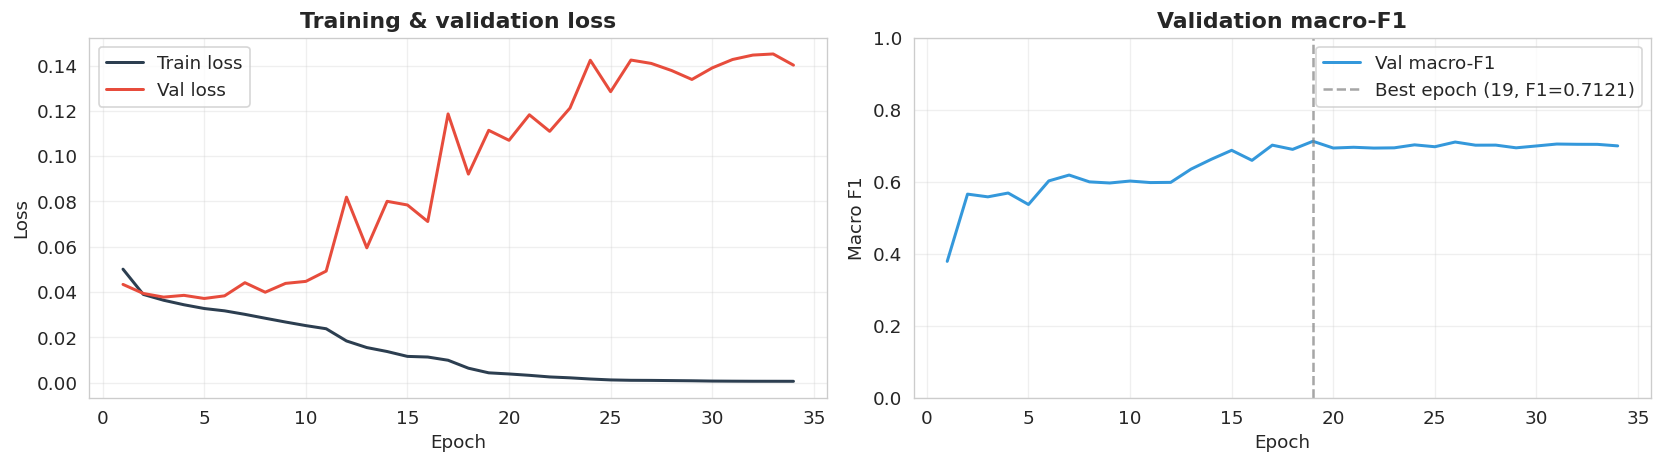

In [10]:
epochs_ran = list(range(1, len(history['train_loss'])+1))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
ax.plot(epochs_ran, history['train_loss'], label='Train loss', color='#2c3e50', linewidth=1.8)
ax.plot(epochs_ran, history['val_loss'],   label='Val loss',   color='#e74c3c', linewidth=1.8)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Training & validation loss', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(epochs_ran, history['val_f1'], label='Val macro-F1', color='#3498db', linewidth=1.8)
ax.axvline(best_ep, color='grey', linestyle='--', alpha=0.7,
           label=f'Best epoch ({best_ep}, F1={best_f1:.4f})')
ax.set_xlabel('Epoch'); ax.set_ylabel('Macro F1')
ax.set_title('Validation macro-F1', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(CKPT_DIR / 'training_curves.png', bbox_inches='tight')
plt.show()


## 9 . Test evaluation

In [11]:
model.load_state_dict(best_state)
_, val_probs_tune, val_tgts_tune = run_epoch(val_loader, model, criterion)
_, test_probs,     test_targets   = run_epoch(te_loader,  model, criterion)
cv_test_probs, cv_test_targets   = val_probs_tune, val_tgts_tune
test_metrics = compute_metrics(test_probs, test_targets)

print(f'Test set: {len(test_probs)} samples')
print(f'{"Class":<6} {"Sensitivity":>12} {"Specificity":>12} {"Accuracy":>10} {"F1":>8}')
print('-'*52)
for cls in CLASS_NAMES:
    m = test_metrics[cls]
    print(f'{cls:<6} {m["sensitivity"]:>12.4f} {m["specificity"]:>12.4f} {m["accuracy"]:>10.4f} {m["f1"]:>8.4f}')
print('-'*52)
print(f'{"Macro":<6} {test_metrics["macro_sensitivity"]:>12.4f} {test_metrics["macro_specificity"]:>12.4f} '
      f'{test_metrics["macro_accuracy"]:>10.4f} {test_metrics["macro_f1"]:>8.4f}')


Test set: 2449 samples
Class   Sensitivity  Specificity   Accuracy       F1
----------------------------------------------------
MI           0.6671       0.9287     0.8408   0.7379
STTC         0.7170       0.8826     0.8293   0.7300
CD           0.7187       0.9008     0.8461   0.7373
HYP          0.5754       0.9459     0.8857   0.6206
----------------------------------------------------
Macro        0.6696       0.9145     0.8504   0.7064


## 9b . Threshold tuning (val set - no leakage)

Per-class threshold tuning (val set - no test leakage):
Class   Best thresh    F1@0.50    F1@best
------------------------------------------
MI             0.32     0.7268     0.7530
STTC           0.30     0.7354     0.7445
CD             0.54     0.7748     0.7793
HYP            0.35     0.6113     0.6258


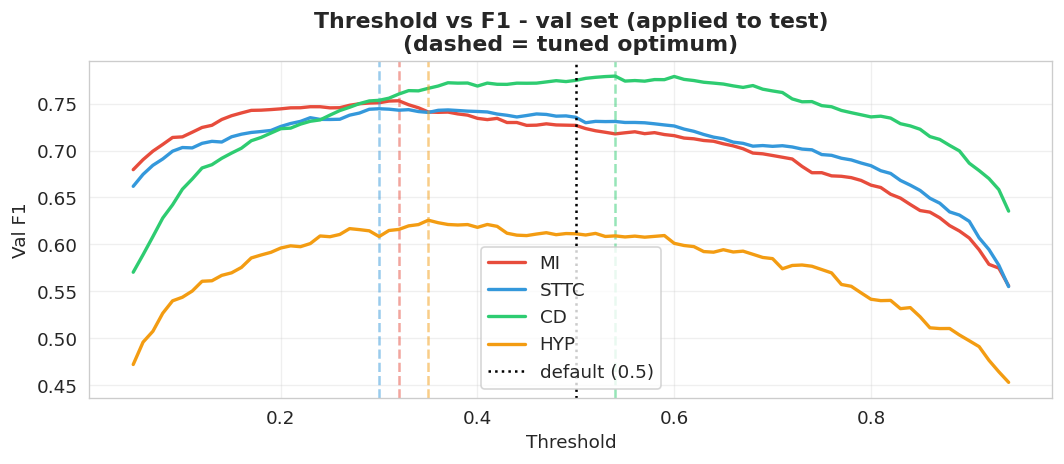


Test - tuned thresholds vs default (0.5):
Class    F1@0.50   F1@tuned     d F1
-------------------------------------
MI        0.7379     0.7483 +0.0104
STTC      0.7300     0.7435 +0.0135
CD        0.7373     0.7351 -0.0022
HYP       0.6206     0.6272 +0.0066
-------------------------------------
Macro     0.7064     0.7135 +0.0071


In [12]:
thresholds_grid  = np.arange(0.05, 0.95, 0.01)
best_thresholds  = {}
thresh_f1_curves = {}

print('Per-class threshold tuning (val set - no test leakage):')
print(f'{"Class":<6} {"Best thresh":>12} {"F1@0.50":>10} {"F1@best":>10}')
print('-'*42)
for i, cls in enumerate(CLASS_NAMES):
    f1s    = [f1_score(cv_test_targets[:,i], (cv_test_probs[:,i]>=t).astype(int), zero_division=0)
              for t in thresholds_grid]
    best_t = thresholds_grid[np.argmax(f1s)]
    f1_50  = f1_score(cv_test_targets[:,i], (cv_test_probs[:,i]>=0.5).astype(int), zero_division=0)
    best_thresholds[cls]  = best_t
    thresh_f1_curves[cls] = f1s
    print(f'{cls:<6} {best_t:>12.2f} {f1_50:>10.4f} {max(f1s):>10.4f}')

fig, ax = plt.subplots(figsize=(9,4))
colors = ['#e74c3c','#3498db','#2ecc71','#f39c12']
for cls, col in zip(CLASS_NAMES, colors):
    ax.plot(thresholds_grid, thresh_f1_curves[cls], label=cls, color=col, linewidth=2)
    ax.axvline(best_thresholds[cls], color=col, linestyle='--', alpha=0.5)
ax.axvline(0.5, color='black', linestyle=':', linewidth=1.5, label='default (0.5)')
ax.set_xlabel('Threshold'); ax.set_ylabel('Val F1')
ax.set_title('Threshold vs F1 - val set (applied to test)\n(dashed = tuned optimum)', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CKPT_DIR / 'threshold_tuning.png', bbox_inches='tight')
plt.show()

tuned_arr           = np.array([best_thresholds[c] for c in CLASS_NAMES])
test_metrics_tuned  = compute_metrics(test_probs, test_targets, tuned_arr)

print(f'\nTest - tuned thresholds vs default (0.5):')
print(f'{"Class":<6} {"F1@0.50":>9} {"F1@tuned":>10} {"d F1":>8}')
print('-'*37)
for cls in CLASS_NAMES:
    d = test_metrics_tuned[cls]['f1'] - test_metrics[cls]['f1']
    print(f'{cls:<6} {test_metrics[cls]["f1"]:>9.4f} {test_metrics_tuned[cls]["f1"]:>10.4f} {d:>+7.4f}')
print('-'*37)
print(f'{"Macro":<6} {test_metrics["macro_f1"]:>9.4f} {test_metrics_tuned["macro_f1"]:>10.4f} '
      f'{test_metrics_tuned["macro_f1"]-test_metrics["macro_f1"]:>+7.4f}')


## 9c . Visualisations

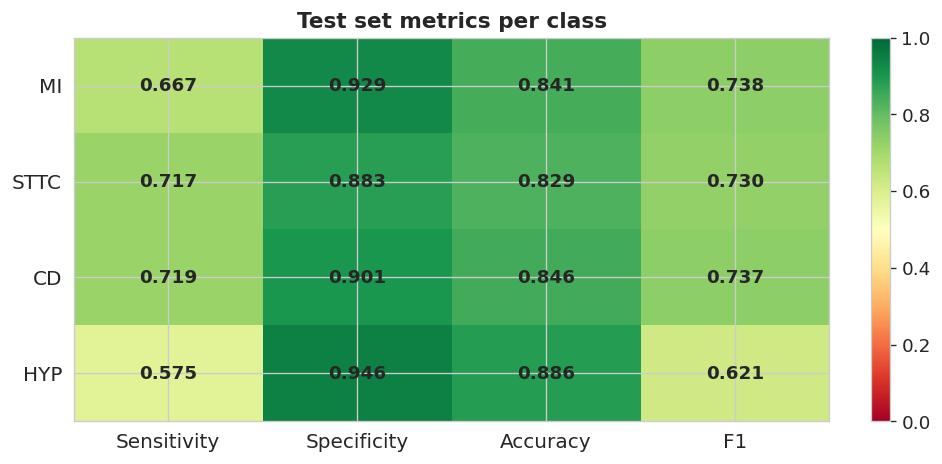

In [13]:
metric_names = ['Sensitivity','Specificity','Accuracy','F1']
metric_keys  = ['sensitivity','specificity','accuracy','f1']
data = np.array([[test_metrics[cls][k] for k in metric_keys] for cls in CLASS_NAMES])
fig, ax = plt.subplots(figsize=(8,4))
im = ax.imshow(data, vmin=0, vmax=1, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(metric_names))); ax.set_xticklabels(metric_names, fontsize=12)
ax.set_yticks(range(len(CLASS_NAMES)));  ax.set_yticklabels(CLASS_NAMES, fontsize=12)
for i in range(len(CLASS_NAMES)):
    for j in range(len(metric_names)):
        ax.text(j, i, f'{data[i,j]:.3f}', ha='center', va='center', fontsize=11, fontweight='bold')
ax.set_title('Test set metrics per class', fontweight='bold', fontsize=13)
plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.savefig(CKPT_DIR / 'metrics_heatmap.png', bbox_inches='tight')
plt.show()


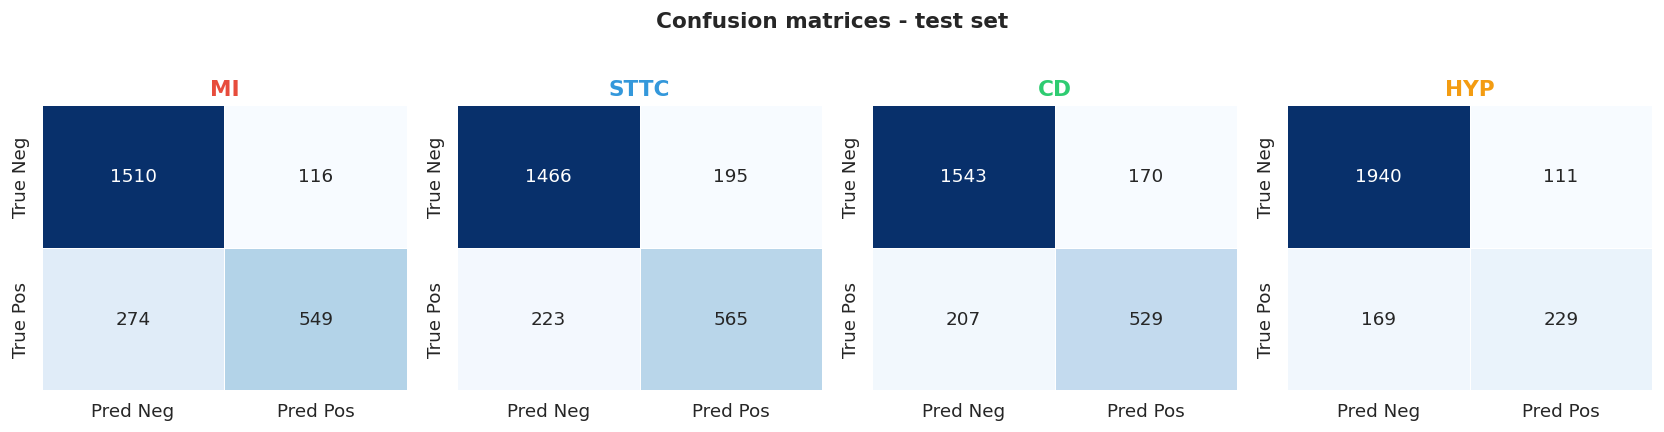

In [14]:
preds_bin = (test_probs >= THRESHOLD).astype(int)
mcm = multilabel_confusion_matrix(test_targets.astype(int), preds_bin)
COLORS = ['#e74c3c','#3498db','#2ecc71','#f39c12']
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(14, 3.5))
for i,(cls,ax) in enumerate(zip(CLASS_NAMES, axes)):
    sns.heatmap(mcm[i], annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred Neg','Pred Pos'], yticklabels=['True Neg','True Pos'],
                cbar=False, linewidths=0.5)
    ax.set_title(cls, fontweight='bold', color=COLORS[i], fontsize=13)
plt.suptitle('Confusion matrices - test set', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(CKPT_DIR / 'confusion_matrices.png', bbox_inches='tight')
plt.show()


## 10 . Summary

In [15]:
print('='*60)
print('  FINAL SUMMARY  |  CNN_BiLSTM_Transformer  |  PTB-XL')
print('='*60)
print(f'Dataset: {len(X_bal)} samples  (NORM undersampled to {NORM_CAP})')
print(f'Split:   {len(X_train_split)} train / {len(X_val_split)} val / {len(X_test_split)} test')
print(f'Best val macro-F1: {best_f1:.4f} @ epoch {best_ep}')
print()
print('Test performance (default threshold 0.5):')
print(f'{"Class":<6} {"Sensitivity":>12} {"Specificity":>12} {"Accuracy":>10} {"F1":>8}')
print('-'*52)
for cls in CLASS_NAMES:
    m = test_metrics[cls]
    print(f'{cls:<6} {m["sensitivity"]:>12.4f} {m["specificity"]:>12.4f} {m["accuracy"]:>10.4f} {m["f1"]:>8.4f}')
print('-'*52)
print(f'{"Macro":<6} {test_metrics["macro_sensitivity"]:>12.4f} {test_metrics["macro_specificity"]:>12.4f} '
      f'{test_metrics["macro_accuracy"]:>10.4f} {test_metrics["macro_f1"]:>8.4f}')
print()
print('Test performance (tuned thresholds):')
print(f'{"Class":<6} {"F1":>8}')
for cls in CLASS_NAMES:
    print(f'{cls:<6} {test_metrics_tuned[cls]["f1"]:>8.4f}')
print(f'{"Macro":<6} {test_metrics_tuned["macro_f1"]:>8.4f}')
print()
for f in sorted(CKPT_DIR.iterdir()):
    if f.is_file():
        print(f'  {f.name:<45} {f.stat().st_size/1024:7.1f} KB')


  FINAL SUMMARY  |  CNN_BiLSTM_Transformer  |  PTB-XL
Dataset: 16347 samples  (NORM undersampled to 4000)
Split:   11474 train / 2424 val / 2449 test
Best val macro-F1: 0.7121 @ epoch 19

Test performance (default threshold 0.5):
Class   Sensitivity  Specificity   Accuracy       F1
----------------------------------------------------
MI           0.6671       0.9287     0.8408   0.7379
STTC         0.7170       0.8826     0.8293   0.7300
CD           0.7187       0.9008     0.8461   0.7373
HYP          0.5754       0.9459     0.8857   0.6206
----------------------------------------------------
Macro        0.6696       0.9145     0.8504   0.7064

Test performance (tuned thresholds):
Class        F1
MI       0.7483
STTC     0.7435
CD       0.7351
HYP      0.6272
Macro    0.7135

  best_model.pt                                  9783.9 KB
  confusion_matrices.png                           35.2 KB
  metrics_heatmap.png                              46.2 KB
  threshold_tuning.png            